## Analysis of Results

Info about scenario ?

In [1]:
# Capacity demand (Implicit)
# Capacity demand = Peak demand - renewables generation during scarcity - imports during scarcity

#### Data extraction

In [2]:
# pip install pyyaml pandas numpy matplotlib scipy

In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Any, List
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


In [4]:
def read_inputs(base_dir: str | Path) -> Dict[str, Any]:
    base_dir = Path(base_dir)
    inp = base_dir / "Input"
    # Load parameters from YAML config
    with open(inp / "config.yaml", "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    H = int(data["General"]["nTimesteps"])

    # Load input files
    load = pd.read_csv(inp / "load.csv", sep=";")
    pv = pd.read_csv(inp / "pv.csv", sep=";")
    wind_on = pd.read_csv(inp / "wind_onshore.csv", sep=";")
    nptdf = pd.read_csv(inp / "nodal_ptdf.csv", sep=";")
    lines = pd.read_csv(inp / "lines.csv", sep=";")
    scarcity_df = pd.read_csv(inp / "scarcity.csv", sep=";")

    # load analysis data files


    # Load weights
    weights_path = inp / "timeseries.csv"
    if weights_path.is_file():
        df_w = pd.read_csv(weights_path, sep=";")
        W = df_w["weights"].astype(float).to_numpy()[:H] if "weights" in df_w else np.ones(H)
        if W.size < H:
            W = np.pad(W, (0, H - W.size), mode="constant", constant_values=1.0)
    else:
        W = np.ones(H)

    return {
        "data": data,
        "load": load,
        "pv": pv,
        "wind_on": wind_on,
        "nptdf": nptdf,
        "lines": lines,
        "weights": W,
        "scarcity": scarcity_df,
    }


if __name__ == "__main__":
    inputs = read_inputs(Path().resolve())
    print(inputs.keys())
print(inputs["load"][:5])


dict_keys(['data', 'load', 'pv', 'wind_on', 'nptdf', 'lines', 'weights', 'scarcity'])
        Unnamed: 0         A        B         C
0  20-3-2025 00:00  45730.25  8211.00  11471.75
1  20-3-2025 01:00  44302.50  7814.25  10987.75
2  20-3-2025 02:00  43733.50  7642.75  10642.75
3  20-3-2025 03:00  44037.75  7500.25  10545.25
4  20-3-2025 04:00  45518.25  7574.25  10644.00


In [5]:
# Load analysis data
def load_analysis_data(base_dir: str | Path) -> Dict[str, pd.DataFrame]:
    base_dir = Path(base_dir)
    analysis_dir = base_dir / "analysis_data"
    categories = ["eom", "explicit_FBMC", "explicit_NTC", "implicit", "pricecap", "NoCBP"]
    data = {}

    for category in categories:
        category_path = analysis_dir / category
        if category_path.is_dir():
            for file in category_path.glob("*.csv"):
                key = f"{file.stem}"
                data[key] = pd.read_csv(file, sep=";")
    return data

if __name__ == "__main__":
    analysis_data = load_analysis_data(Path().resolve())
    print(analysis_data.keys())
    
analysis_data["planner_zone_A_eom"][:5]

dict_keys(['mcp_zone_A_eom', 'mcp_zone_B_eom', 'mcp_zone_C_eom', 'planner_zone_A_eom', 'planner_zone_B_eom', 'planner_zone_C_eom', 'mcp_zone_A_FBMC', 'mcp_zone_B_FBMC', 'mcp_zone_C_FBMC', 'planner_zone_A_FBMC', 'planner_zone_B_FBMC', 'planner_zone_C_FBMC', 'mcp_zone_A_NTC', 'mcp_zone_B_NTC', 'mcp_zone_C_NTC', 'planner_zone_A_NTC', 'planner_zone_B_NTC', 'planner_zone_C_NTC', 'mcp_zone_A_implicit', 'mcp_zone_B_implicit', 'mcp_zone_C_implicit', 'planner_zone_A_implicit', 'planner_zone_B_implicit', 'planner_zone_C_implicit', 'mcp_zone_A_pricecap', 'mcp_zone_B_pricecap', 'mcp_zone_C_pricecap', 'planner_zone_A_pricecap', 'planner_zone_B_pricecap', 'planner_zone_C_pricecap', 'mcp_zone_A_NoCBP', 'mcp_zone_B_NoCBP', 'mcp_zone_C_NoCBP', 'planner_zone_A_NoCBP', 'planner_zone_B_NoCBP', 'planner_zone_C_NoCBP'])


,Timestep,EOM_price,Gen_A_Baseload,new_Capacity_Gen_A_Baseload,Capacity_Gen_A_Baseload,Gen_A_MidMerit,new_Capacity_Gen_A_MidMerit,Capacity_Gen_A_MidMerit,Gen_A_PV,new_Capacity_Gen_A_PV,...,new_Capacity_Gen_A_Peak,Capacity_Gen_A_Peak,Gen_A_WindOnshore,new_Capacity_Gen_A_WindOnshore,Capacity_Gen_A_WindOnshore,Cons_A,Inelastic_Cons_A,Elastic_Cons_A,NetworkManager,ENS_Cons_A
0,1.0,55.77,27751.44,27751.44,27751.44,1489.81,9491.64,9491.64,0.0,0.0,...,6494.93,6494.93,22045.75,0.0,72618.0,45704.75,36584.2,9120.55,-5582.25,0.0
1,2.0,54.61,27751.44,27751.44,27751.44,1127.54,9491.64,9491.64,0.0,0.0,...,6494.93,6494.93,20881.00,0.0,72618.0,44278.31,35442.0,8836.31,-5481.67,0.0
2,3.0,55.13,27751.44,27751.44,27751.44,1290.43,9491.64,9491.64,0.0,0.0,...,6494.93,6494.93,20062.25,0.0,72618.0,43709.39,34986.8,8722.59,-5394.73,0.0
3,4.0,56.29,27751.44,27751.44,27751.44,1654.27,9491.64,9491.64,0.0,0.0,...,6494.93,6494.93,19590.50,0.0,72618.0,44012.96,35230.2,8782.76,-4983.25,0.0
4,5.0,58.82,27751.44,27751.44,27751.44,2442.67,9491.64,9491.64,0.0,0.0,...,6494.93,6494.93,19433.00,0.0,72618.0,45491.48,36414.6,9076.88,-4135.64,0.0


#### Capacity plots

In [6]:
# select either "planner" or "mcp" data by changing the key construction below
def extract_total_capacity(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]

    records = []
    for design_key in design_keys:
        for zone in zones:
            # Construct the key
            # key = f"planner_zone_{zone}_{design_key}"
            key = f"mcp_zone_{zone}_{design_key}"
            if key not in data:
                print(f"Key not found: {key}")  # Debugging statement
                continue
            df = data[key]
            row = {"Zone": zone, "Design": design_key}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                row[g] = df[col].iloc[0] if col in df.columns else 0  # Use the first value
            records.append(row)

        # Add "Com" (combined)
        total = {"Zone": "Com", "Design": design_key}
        for g in gen_types:
            total[g] = sum(r[g] for r in records if r["Design"] == design_key)
        records.append(total)

    return pd.DataFrame(records)

In [7]:
extract_total_capacity(analysis_data)

,Zone,Design,Baseload,MidMerit,Peak
0,A,eom,28365.146795,9623.419805,8020.284465
1,B,eom,4200.315131,1520.237318,912.200191
2,C,eom,5143.086496,2847.735844,3252.859107
3,Com,eom,37708.548422,13991.392967,12185.343763
4,A,FBMC,28343.936861,9668.848501,16769.051346
5,B,FBMC,4598.730205,1895.351942,5801.529885
6,C,FBMC,4698.788147,2341.657701,14277.490352
7,Com,FBMC,37641.455213,13905.858144,36848.071584
8,A,NTC,28350.118123,9655.462593,13333.498993
9,B,NTC,4599.264860,1898.862397,10107.432847


In [8]:
def extract_capacity_changes(df: pd.DataFrame, ref_design="eom") -> pd.DataFrame:
    zones = ["A", "B", "C", "Com"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    deltas = []

    base_df = df[df["Design"] == ref_design]

    for design in df["Design"].unique():
        if design == ref_design:
            continue
        for zone in zones:
            base = base_df[(base_df["Zone"] == zone)]
            current = df[(df["Zone"] == zone) & (df["Design"] == design)]
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                base_val = base[g].values[0] if not base.empty else 0
                curr_val = current[g].values[0] if not current.empty else 0
                delta[g] = curr_val - base_val
            deltas.append(delta)

    return pd.DataFrame(deltas)

In [9]:
def plot_capacity_bars(df: pd.DataFrame, ylabel: str):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        design_start_pos = pos
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    bottom = np.zeros(len(x_labels))

    fig, ax = plt.subplots(figsize=(14, 6))
    for g in gen_types:
        ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
        bottom += np.array(data[g])

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(0, bottom.max() * 1.1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    
    # Add market design labels as text
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, design, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

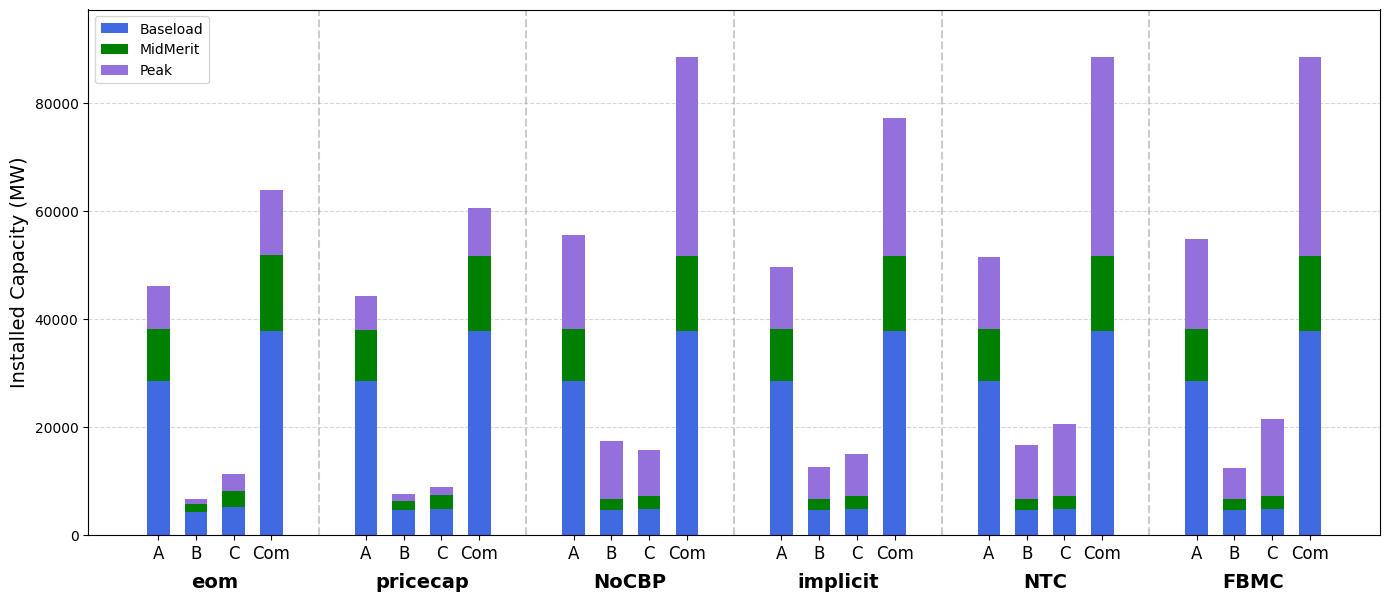

In [10]:
# Extract capacity data
capacity_data = extract_total_capacity(analysis_data)

# Plot total capacity
plot_capacity_bars(capacity_data, "Installed Capacity (MW)")


In [11]:
def extract_planner_mcp_diffs(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]
    
    deltas = []
    
    for design in design_keys:
        for zone in zones:
            planner_key = f"planner_zone_{zone}_{design}"
            mcp_key = f"mcp_zone_{zone}_{design}"
            
            if planner_key not in data or mcp_key not in data:
                print(f"Key not found: {planner_key} or {mcp_key}")
                continue
                
            planner_df = data[planner_key]
            mcp_df = data[mcp_key]
            
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                
                planner_val = planner_df[col].iloc[0] if col in planner_df.columns else 0
                mcp_val = mcp_df[col].iloc[0] if col in mcp_df.columns else 0

                delta[g] = mcp_val - planner_val

            deltas.append(delta)
    
    # Add "Com" (combined) for each design
    for design in design_keys:
        design_deltas = [d for d in deltas if d["Design"] == design]
        if not design_deltas:
            continue
            
        com_delta = {"Zone": "Com", "Design": design}
        for g in gen_types:
            com_delta[g] = sum(d[g] for d in design_deltas)
        deltas.append(com_delta)
    
    return pd.DataFrame(deltas)

In [12]:
def plot_cap_bars(df: pd.DataFrame, ylabel: str, allow_negatives=True):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Handle positive and negative values differently for proper stacking
    if allow_negatives:
        # For data with positive and negative values
        bottom_pos = np.zeros(len(x_labels))
        bottom_neg = np.zeros(len(x_labels))
        
        for g in gen_types:
            data_array = np.array(data[g])
            mask_pos = data_array >= 0
            mask_neg = data_array < 0
            
            # Plot positive values (stack upward)
            ax.bar(np.array(x_positions)[mask_pos], data_array[mask_pos], 
                  width, bottom=bottom_pos[mask_pos], color=colors[g], label=g if g not in ax.get_legend_handles_labels()[1] else "")
            bottom_pos[mask_pos] += data_array[mask_pos]
            
            # Plot negative values (stack downward)
            ax.bar(np.array(x_positions)[mask_neg], data_array[mask_neg], 
                  width, bottom=bottom_neg[mask_neg], color=colors[g])
            bottom_neg[mask_neg] += data_array[mask_neg]
        
        # Calculate proper y-axis limits to show both positive and negative values
        y_max = bottom_pos.max() * 1.1 if bottom_pos.max() > 0 else 1
        y_min = bottom_neg.min() * 1.1 if bottom_neg.min() < 0 else -1
        ax.set_ylim(y_min, y_max)
        
    else:
        # Original implementation for positive-only data
        bottom = np.zeros(len(x_labels))
        for g in gen_types:
            ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
            bottom += np.array(data[g])
        ax.set_ylim(0, bottom.max() * 1.1)

    # Add zero line if we have negative values
    if allow_negatives:
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    
    # Add market design labels as text (adjusted for new spacing)
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, design, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

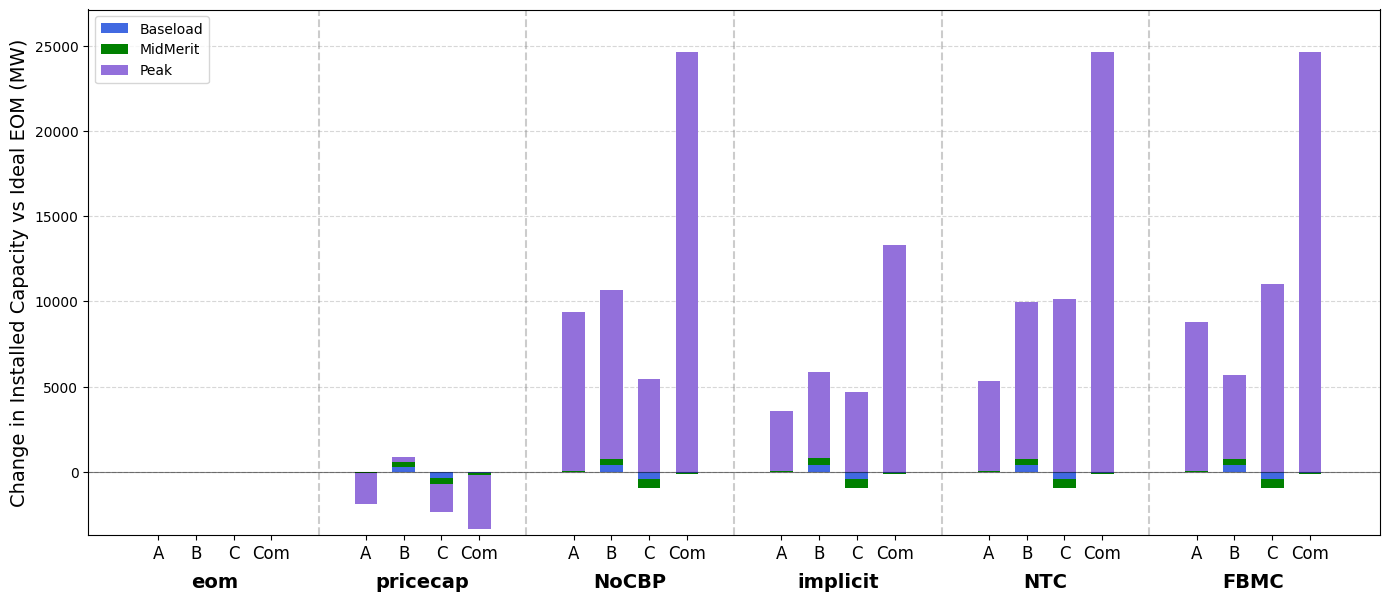

In [13]:
# plot capacity changes
capacity_changes = extract_capacity_changes(capacity_data)
plot_cap_bars(capacity_changes,"Change in Installed Capacity vs Ideal EOM (MW)")

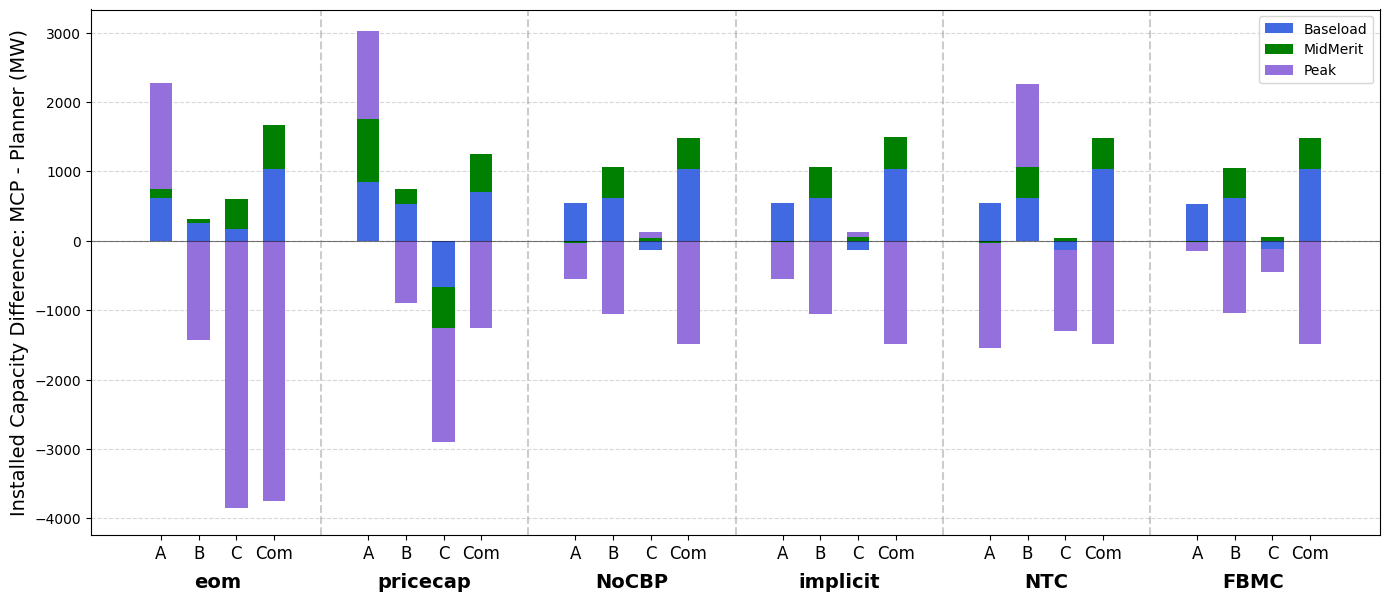

In [14]:
# Extract differences between planner and MCP models
planner_mcp_diffs = extract_planner_mcp_diffs(analysis_data)
plot_cap_bars(planner_mcp_diffs, "Installed Capacity Difference: MCP - Planner (MW)")

#### Network flows

In [15]:
def plot_net_positions(data: Dict[str, pd.DataFrame], source_type: str = "planner"):
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    colors = {"import": "#C0C0C0", "export": "#9370DB"}
    bar_width = 0.7  # Wider single bar

    fig, ax = plt.subplots(figsize=(14, 7))

    # Set positions for bars (one position per zone per design)
    n_designs = len(design_keys)
    n_zones = len(zones)
    total_groups = n_designs * n_zones
    indices = np.arange(total_groups)

    imports = []
    exports = []

    # Build grouped data
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            net_import = 0
            net_export = 0

            if key in data and "NetworkManager" in data[key].columns:
                flows = data[key]["NetworkManager"].values
                net_import = flows[flows >= 0].sum()
                net_export = abs(flows[flows < 0].sum())  # Make exports positive for plotting

            imports.append(net_import)
            exports.append(-net_export)  # Store as negative for plotting below x-axis

    # Plotting both imports and exports in one bar
    ax.bar(indices, imports, bar_width, label="Net import", color=colors["import"])
    ax.bar(indices, exports, bar_width, label="Net export", color=colors["export"])

    # Annotate values on bars
    # for idx, (imp, exp) in enumerate(zip(imports, exports)):
    #     if imp > 0:
    #         ax.text(idx, imp/2, f"{abs(imp):.1f}", ha='center', va='top', fontsize=9)
    #     if exp < 0:
    #         ax.text(idx, exp/2, f"{abs(exp):.1f}", ha='center', va='bottom', fontsize=9)

    # Add vertical design group labels
    for i, design in enumerate(design_keys):
        center = i * len(zones) + 1  # Middle of each group
        max_val = max([max(imports), abs(min(exports))]) if imports or exports else 1
        ax.text(center, max_val + 2.5, design, ha='center', va='bottom', fontsize=14)

    # Gridlines and axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Energy flows [MWh]", fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Set x-ticks as zone names within each design
    ax.set_xticks(indices)
    ax.set_xticklabels(zones * len(design_keys))

    # Add vertical lines between groups
    for i in range(1, n_designs):
        ax.axvline(i * n_zones - 0.5, color='gray', linestyle='--', alpha=0.6)

    ax.legend(loc='upper left')
    
    # Set symmetric y-limits for better visual comparison
    y_limit = max(max(imports), abs(min(exports))) * 1.1
    ax.set_ylim(-y_limit, y_limit)
    
    plt.tight_layout()

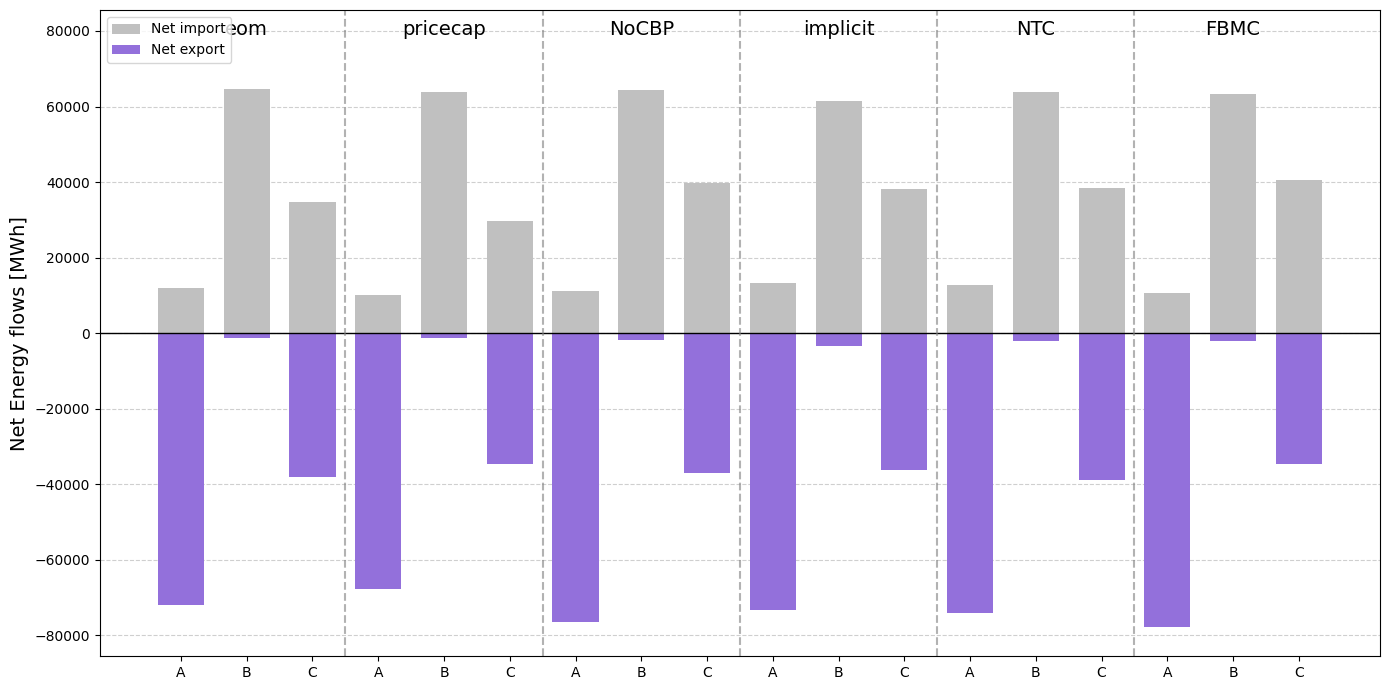

In [16]:
# Visualize net positions by zone
plot_net_positions(analysis_data, source_type="planner")

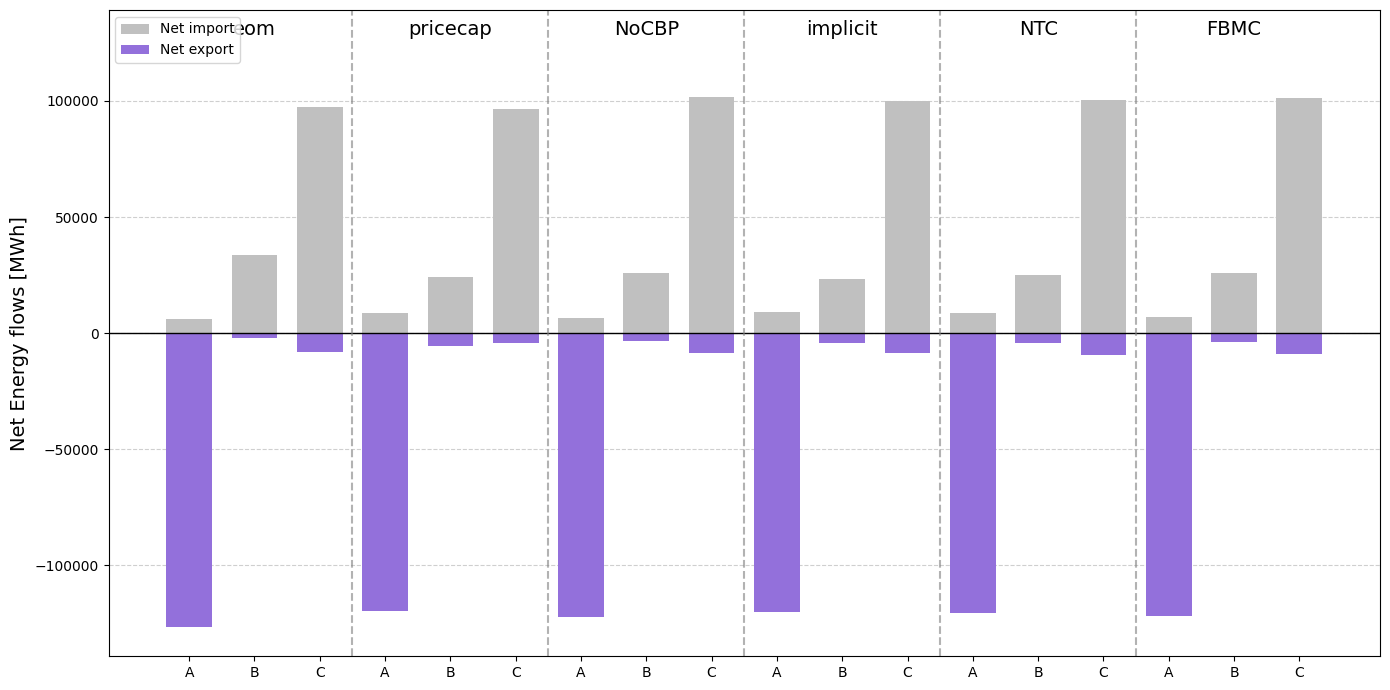

In [17]:
plot_net_positions(analysis_data, source_type="mcp")

In [18]:
# Congestion Rent
# implicit:
# zone A :
# zone B :
# zone C :


# ATC:
# zone A :
# zone B :
# zone C :

# FBMC:
# zone A :
# zone B :
# zone C :


In [19]:
# Net capacity trade

In [20]:
# capacity congestion rent

#### Demand Analysis

In [21]:
def residual_demand(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, np.ndarray]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    
    # Process each design and zone
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                # Get the load for this zone
                # zone_load = inputs["load"][zone].values if zone in inputs["load"].columns else inputs["load"]["zone"].values
                cons = f"Cons_{zone}"
                zone_load = data[key][cons].values if cons in data[key].columns else np.zeros_like(data[key][cons].values)
                
                # Calculate renewable generation for this zone
                wind_col = f"Gen_{zone}_WindOnshore"
                pv_col = f"Gen_{zone}_PV"
                
                # Check if renewable generation columns exist
                wind = data[key][wind_col].values if wind_col in data[key].columns else np.zeros_like(zone_load)
                pv = data[key][pv_col].values if pv_col in data[key].columns else np.zeros_like(zone_load)
                
                # Calculate residual load at time step
                total_ren_gen = wind + pv
                result[design][zone] = np.maximum(zone_load - total_ren_gen, 0.0)
    
    return result

In [22]:
def plot_residual_load(residual_loads: Dict[str, Dict[str, np.ndarray]], design: str = "eom"):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Define custom zone colors
    zone_colors = {
        "A": "royalblue", 
        "B": "green", 
        "C": "mediumpurple"
    }
    
    # Get weights for proper duration curve
    W = inputs["weights"]
    
    for zone in ["A", "B", "C"]:
        if residual_loads[design][zone] is not None:
            loads = residual_loads[design][zone]
            weights = W[:len(loads)]
            
            # Apply weights to create weighted duration curve
            # Sort load values in descending order along with their weights
            sorted_indices = np.argsort(loads)[::-1]
            sorted_loads = loads[sorted_indices]
            sorted_weights = weights[sorted_indices]
            
            # Calculate cumulative weights for x-axis percentages
            cumulative_weights = np.cumsum(sorted_weights)
            percent_duration = 100.0 * cumulative_weights / cumulative_weights[-1]
            
            # Plot the weighted duration curve
            ax.plot(percent_duration, sorted_loads, label=f"Zone {zone}", 
                    color=zone_colors[zone], linewidth=3)
    
    # Add zero line for better visualization
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel("Duration (%)", fontsize=14)
    ax.set_ylabel("Residual Load (MW)", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

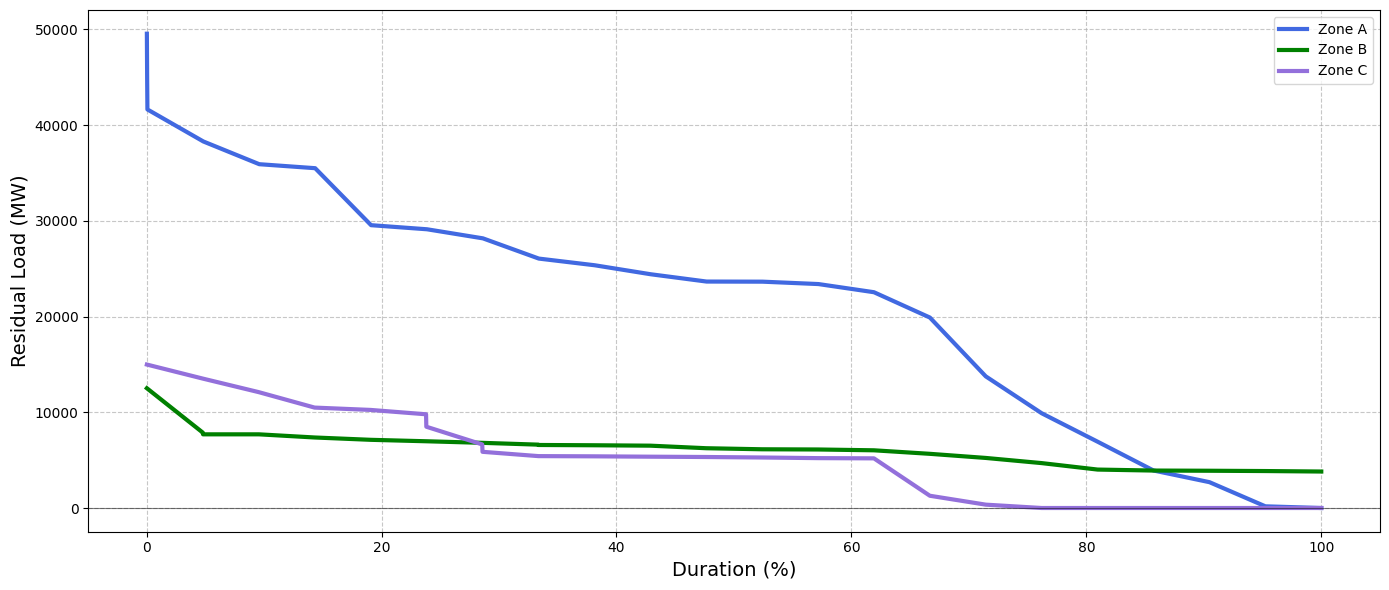

In [23]:
# Calculate residual loads if not already done
res_loads = residual_demand(analysis_data, source_type="planner")
# Plot for different designs
plot_residual_load(res_loads, design="eom")
# plot_residual_load(res_loads, design="pricecap")

In [24]:

# Capacity demand (No CBP) - total residual demand that needs to be met by capacity mechanisms
# We use the ideal central planner results to compute capacity demand in zone A
# Capacity demand = Peak demand - renewables generation during scarcity


def capacity_demand(analysis_data: Dict[str, pd.DataFrame]):
    zones = ["A", "B", "C"]
    for design in ["eom"]:  # Just check one design type
        for zone in zones:
            key = f"planner_zone_{zone}_{design}"
            
            if key in analysis_data:
                # Get consumption data
                cons_col = f"Cons_{zone}"
                if cons_col in analysis_data[key].columns:
                    # Find the peak load and its time index
                    peak_load = analysis_data[key][cons_col].max()
                    peak_index = analysis_data[key][cons_col].idxmax()
                    
                    # Get renewable generation at peak load time
                    wind_col = f"Gen_{zone}_WindOnshore"
                    pv_col = f"Gen_{zone}_PV"

                    network_manager_col = "NetworkManager"
                    net_pos = analysis_data[key].at[peak_index, network_manager_col] if network_manager_col in analysis_data[key].columns else 0

                    
                    wind_gen = analysis_data[key].at[peak_index, wind_col] if wind_col in analysis_data[key].columns else 0
                    pv_gen = analysis_data[key].at[peak_index, pv_col] if pv_col in analysis_data[key].columns else 0
                    total_ren_gen = wind_gen + pv_gen
                    
                    # Calculate residual peak demand
                    residual_peak = peak_load - total_ren_gen
                    explicit_peak = residual_peak + net_pos # Adjust for imports during scarcity
                    
                    
                    print(f"Zone {zone}:")
                    print(f"  Peak load: {peak_load:.2f} MW")
                    print(f"  Renewable generation during peak: {total_ren_gen:.2f} MW")
                    print(f"  Capacity demand (implicit): {residual_peak:.2f} MW")
                    print(f"  Import during scarcity period: {net_pos:.2f} MW")
                    print(f"  Capacity demand (explicit): {explicit_peak:.2f} MW")
                    print()

# Call the function
capacity_demand(analysis_data)

# view of the state of the network during scarcity scenario A

Zone A:
  Peak load: 82151.45 MW
  Renewable generation during peak: 32598.75 MW
  Capacity demand (implicit): 49552.70 MW
  Import during scarcity period: 5844.35 MW
  Capacity demand (explicit): 55397.05 MW

Zone B:
  Peak load: 13007.92 MW
  Renewable generation during peak: 494.86 MW
  Capacity demand (implicit): 12513.06 MW
  Import during scarcity period: 4772.70 MW
  Capacity demand (explicit): 17285.76 MW

Zone C:
  Peak load: 17135.22 MW
  Renewable generation during peak: 2146.45 MW
  Capacity demand (implicit): 14988.77 MW
  Import during scarcity period: 723.80 MW
  Capacity demand (explicit): 15712.57 MW



#### Cost analysis

In [25]:
# cost of electricity (€)
# electricity_price*weight(€/MWh) * electricity_demand*weight (MWh)


# cost of unserved energy(€)
# ENS*weight(MWh)
# WTP = 20000 (€/MWh)
# cost of unserved energy = WTP * ENS 



# cost of capacity market (€)
# capacity_market_cost = capacity_price (€/MW) * capacity demand (MW)


# total demand served = (elastic + inelastic demand served).weight (MWh)

# Average prices across zones (€/MWh) =  (cost of electricity (€) + cost of unserved energy(€) + cost of capacity market (€)) / total demand served (MWh)


In [26]:
def extract_cost_data(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, pd.DataFrame]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                result[design][zone] = data[key]
            else:
                print(f"Warning: Missing data for {key}")
    
    return result

In [27]:
# extract_cost_data(analysis_data, source_type="planner")

In [28]:
def compute_cost_metrics(cost_data: Dict[str, Dict[str, pd.DataFrame]], weights: np.ndarray, 
                         wtp: float = 20000) -> pd.DataFrame:

    zones = ["A", "B", "C"]
    design_keys = list(cost_data.keys())
    records = []
    
    for design in design_keys:
        zone_records = []  # Track records for this design
        
        for zone in zones:
            if cost_data[design][zone] is None:
                continue
            
            df = cost_data[design][zone]
            W = weights[:len(df)]  # Get weights for the correct length
            
            # 1. Calculate electricity cost
            elec_price_col = f"EOM_price" if f"EOM_price" in df.columns else "Price"
            elec_demand_col = f"Cons_{zone}" if f"Cons_{zone}" in df.columns else "Demand"

            if elec_price_col in df.columns and elec_demand_col in df.columns:
                # For each timestep: price * demand * weight
                electricity_cost = np.sum(df[elec_price_col] * df[elec_demand_col].abs() * W)
            else:
                print(f"Missing columns for electricity cost calculation in {design} - {zone}")
                electricity_cost = 0
                
            # 2. Calculate unserved energy cost
            ens_col = f"ENS_Cons_{zone}" if f"ENS_Cons_{zone}" in df.columns else "ENS"
            if ens_col in df.columns:
                ens = abs(df[ens_col].values)
                ens_cost = np.sum(ens * W * wtp)
                total_ens = np.sum(ens * W)
            else:
                print(f"Missing ENS column in {design} - {zone}")
                ens_cost = 0
                total_ens = 0
                
            # 3. Calculate capacity market cost
            cap_price_col = f"CM_price" if f"CM_price" in df.columns else "CapacityPrice"
            cap_demand_col = f"CapDemand_Cons_{zone}" if f"CapDemand_Cons_{zone}" in df.columns else "CapacityDemand"
            
            if cap_price_col in df.columns and cap_demand_col in df.columns:
                cap_price = df[cap_price_col].values[0]
                cap_demand = abs(df[cap_demand_col].values[0])
                capacity_cost = cap_price * cap_demand # (€/MW * MW)
            else:
                capacity_cost = 0
                
            # 4. Calculate total demand served (using electricity demand, not capacity demand)
            if elec_demand_col in df.columns:
                # Get values, convert to positive, apply weights
                total_served = np.sum(abs(df[elec_demand_col].values) * W)
            else:
                total_served = 0
            
            # 5. Calculate average price
            total_cost = electricity_cost + ens_cost + capacity_cost
            avg_price = total_cost / total_served if total_served > 0 else 0
            
            record = {
                "Zone": zone,
                "Design": design,
                "ElectricityCost": electricity_cost,
                "ENSCost": ens_cost,
                "CapacityCost": capacity_cost,
                "TotalCost": total_cost,
                "DemandServed": total_served,
                "AveragePrice": avg_price,
                "ENS": total_ens
            }
            
            records.append(record)
            zone_records.append(record)
        
        # Calculate system-wide metrics for this design
        # Rest of the function remains the same
        # ...
        
        # Calculate system-wide metrics for this design (one per design)
        if zone_records:  # Only if we have zone records for this design
            elec_cost_sum = sum(r["ElectricityCost"] for r in zone_records)
            ens_cost_sum = sum(r["ENSCost"] for r in zone_records)
            cap_cost_sum = sum(r["CapacityCost"] for r in zone_records)
            total_cost_sum = sum(r["TotalCost"] for r in zone_records)
            demand_served_sum = sum(r["DemandServed"] for r in zone_records)
            total_ens = sum(r["ENS"] for r in zone_records)

            # Calculate system-wide average price
            avg_price = total_cost_sum / demand_served_sum if demand_served_sum > 0 else 0
            
            records.append({
                "Zone": "System",
                "Design": design,
                "ElectricityCost": elec_cost_sum,
                "ENSCost": ens_cost_sum,
                "CapacityCost": cap_cost_sum,
                "TotalCost": total_cost_sum,
                "DemandServed": demand_served_sum,
                "AveragePrice": avg_price,
                "ENS": total_ens
            })
    
    return pd.DataFrame(records)

In [29]:
compute_cost_metrics(extract_cost_data(analysis_data, source_type="mcp"), inputs["weights"])

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,3.305449e+10,0.000000e+00,0.000000e+00,3.305449e+10,4.731854e+08,69.855261,0.000000e+00
1,B,eom,6.090699e+09,3.637979e-08,0.000000e+00,6.090699e+09,7.922241e+07,76.881004,1.818989e-12
2,C,eom,8.984830e+09,0.000000e+00,0.000000e+00,8.984830e+09,1.103429e+08,81.426469,0.000000e+00
3,System,eom,4.813002e+10,3.637979e-08,0.000000e+00,4.813002e+10,6.627507e+08,72.621605,1.818989e-12
4,A,pricecap,3.281563e+10,7.134252e+08,0.000000e+00,3.352906e+10,4.731587e+08,70.862173,3.567126e+04
5,B,pricecap,6.089163e+09,3.271442e+08,0.000000e+00,6.416308e+09,7.920566e+07,81.008196,1.635721e+04
6,C,pricecap,8.797279e+09,3.933569e+08,0.000000e+00,9.190636e+09,1.103252e+08,83.304987,1.966784e+04
7,System,pricecap,4.770207e+10,1.433926e+09,0.000000e+00,4.913600e+10,6.626896e+08,74.146332,7.169632e+04
8,A,NoCBP,2.863953e+10,8.016717e+07,4.012192e+09,3.273189e+10,4.732340e+08,69.166405,4.008359e+03
9,B,NoCBP,5.480972e+09,4.365575e-07,1.210003e+09,6.690975e+09,7.922888e+07,84.451214,2.182787e-11


In [30]:
def plot_average_cost_by_zone(cost_metrics: pd.DataFrame):


    fig, ax = plt.subplots(figsize=(16, 8))

    zones = ["A", "B", "C", "System"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors
    base_colors = {
        "A": "#1f77b4",       # Blue
        "B": "#2ca02c",       # Green
        "C": "#9467bd",       # Purple
        "System": "#d62728"   # Red
    }

    # Function to create shades
    def get_shades(hex_color):
        rgb = mcolors.to_rgb(hex_color)
        return {
            "ENERGY": mcolors.to_hex(rgb),                           # original
            "CM": mcolors.to_hex([min(1, c + 0.2) for c in rgb]),    # medium lightness
            "ENS": mcolors.to_hex([min(1, c + 0.4) for c in rgb])   # lightest
        }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = cost_metrics[cost_metrics["Zone"] == zone]
        zone_start_x = current_x
        shades = get_shades(base_colors[zone])

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            energy = row["ElectricityCost"].values[0] / row["DemandServed"].values[0]
            ens = row["ENSCost"].values[0] / row["DemandServed"].values[0]
            cm = row["CapacityCost"].values[0] / row["DemandServed"].values[0]
            total = energy + ens + cm

            # Bars with shade logic
            ax.bar(current_x, energy, width=bar_width, color=shades["ENERGY"])
            ax.bar(current_x, ens, width=bar_width, bottom=energy, color=shades["ENS"])
            ax.bar(current_x, cm, width=bar_width, bottom=energy + ens, color=shades["CM"])

            # Label total on top
            ax.text(current_x, total + 1, f"{total:.2f}", ha="center", va="bottom", fontsize=9)

            # Record positions
            x_positions.append(current_x)
            x_labels.append(design)
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"{zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.2, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Average Cost (€/MWh)', fontsize=13)
    ax.set_ylim(0, max(cost_metrics["AveragePrice"]) * 1.3)
    # ax.set_title("Average Cost to Consumers by Zone and Market Design", fontsize=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Custom legend - fixed colors and better aligned with chart
    sample_shades = get_shades("#777777")  # Neutral color for legend
    
    # Create legend handles and labels separately
    legend_handles = [
        Patch(facecolor=sample_shades["ENERGY"]),
        Patch(facecolor=sample_shades["CM"]),
        Patch(facecolor=sample_shades["ENS"])
    ]
    legend_labels = ['ENERGY', 'CM', 'ENS']
    
    # Add legend with separated handles and labels
    ax.legend(handles=legend_handles, labels=legend_labels, loc='upper left', fontsize=10)

    plt.tight_layout()
    return fig, ax

def analyze_costs(analysis_data, inputs, source_type=""):
    # Extract cost data
    cost_data = extract_cost_data(analysis_data, source_type)
    
    # Compute cost metrics
    cost_metrics = compute_cost_metrics(cost_data, inputs["weights"])
    
    # Create visualizations
    fig, ax = plot_average_cost_by_zone(cost_metrics)
    plt.show()  # Add this to ensure plot is displayed
    return cost_metrics



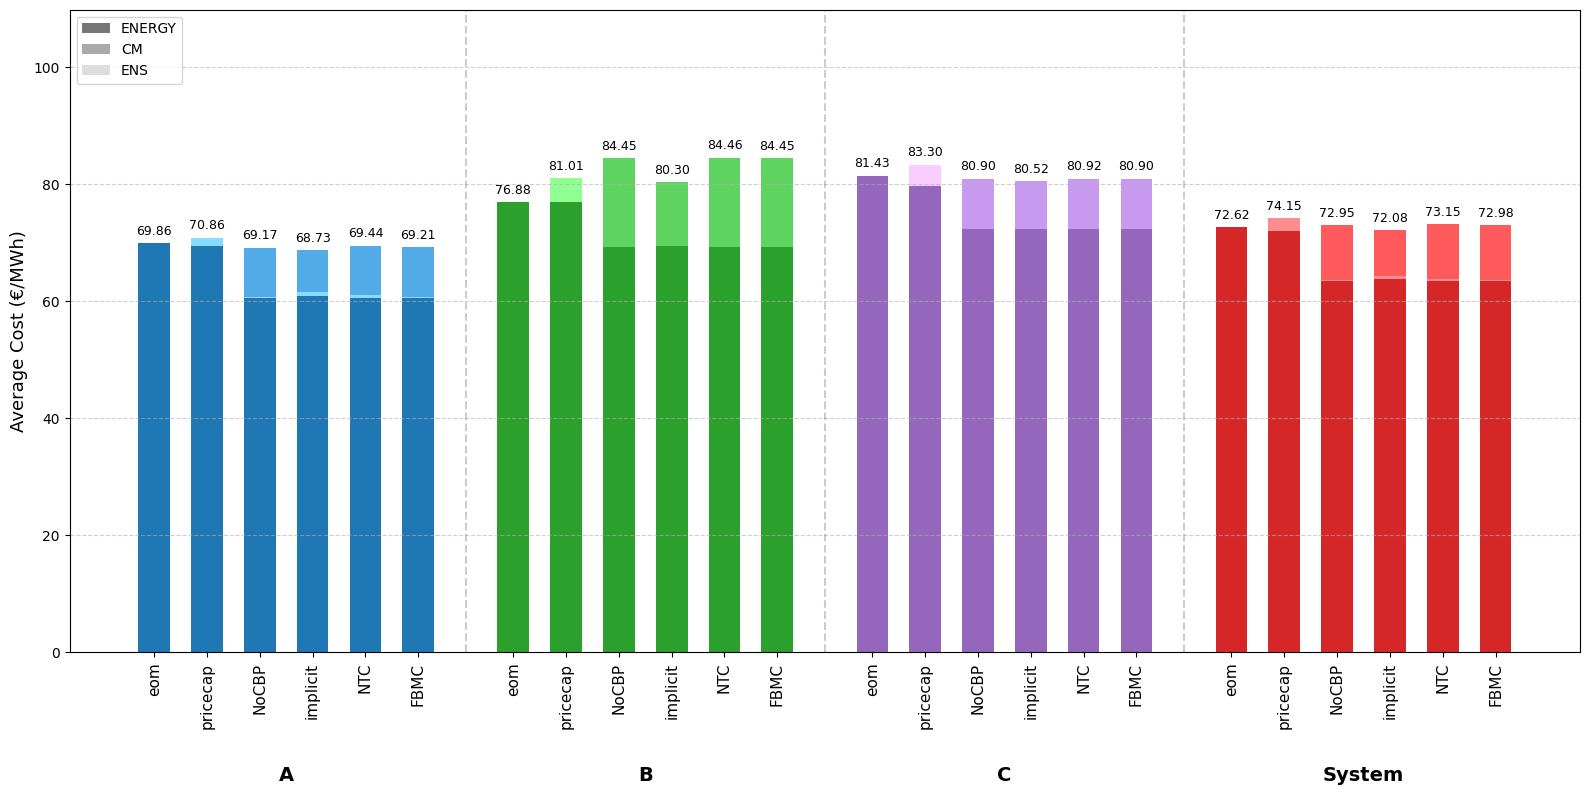

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,3.305449e+10,0.000000e+00,0.000000e+00,3.305449e+10,4.731854e+08,69.855261,0.000000e+00
1,B,eom,6.090699e+09,3.637979e-08,0.000000e+00,6.090699e+09,7.922241e+07,76.881004,1.818989e-12
2,C,eom,8.984830e+09,0.000000e+00,0.000000e+00,8.984830e+09,1.103429e+08,81.426469,0.000000e+00
3,System,eom,4.813002e+10,3.637979e-08,0.000000e+00,4.813002e+10,6.627507e+08,72.621605,1.818989e-12
4,A,pricecap,3.281563e+10,7.134252e+08,0.000000e+00,3.352906e+10,4.731587e+08,70.862173,3.567126e+04
5,B,pricecap,6.089163e+09,3.271442e+08,0.000000e+00,6.416308e+09,7.920566e+07,81.008196,1.635721e+04
6,C,pricecap,8.797279e+09,3.933569e+08,0.000000e+00,9.190636e+09,1.103252e+08,83.304987,1.966784e+04
7,System,pricecap,4.770207e+10,1.433926e+09,0.000000e+00,4.913600e+10,6.626896e+08,74.146332,7.169632e+04
8,A,NoCBP,2.863953e+10,8.016717e+07,4.012192e+09,3.273189e+10,4.732340e+08,69.166405,4.008359e+03
9,B,NoCBP,5.480972e+09,4.365575e-07,1.210003e+09,6.690975e+09,7.922888e+07,84.451214,2.182787e-11


In [31]:
analyze_costs(analysis_data, inputs, source_type="mcp")

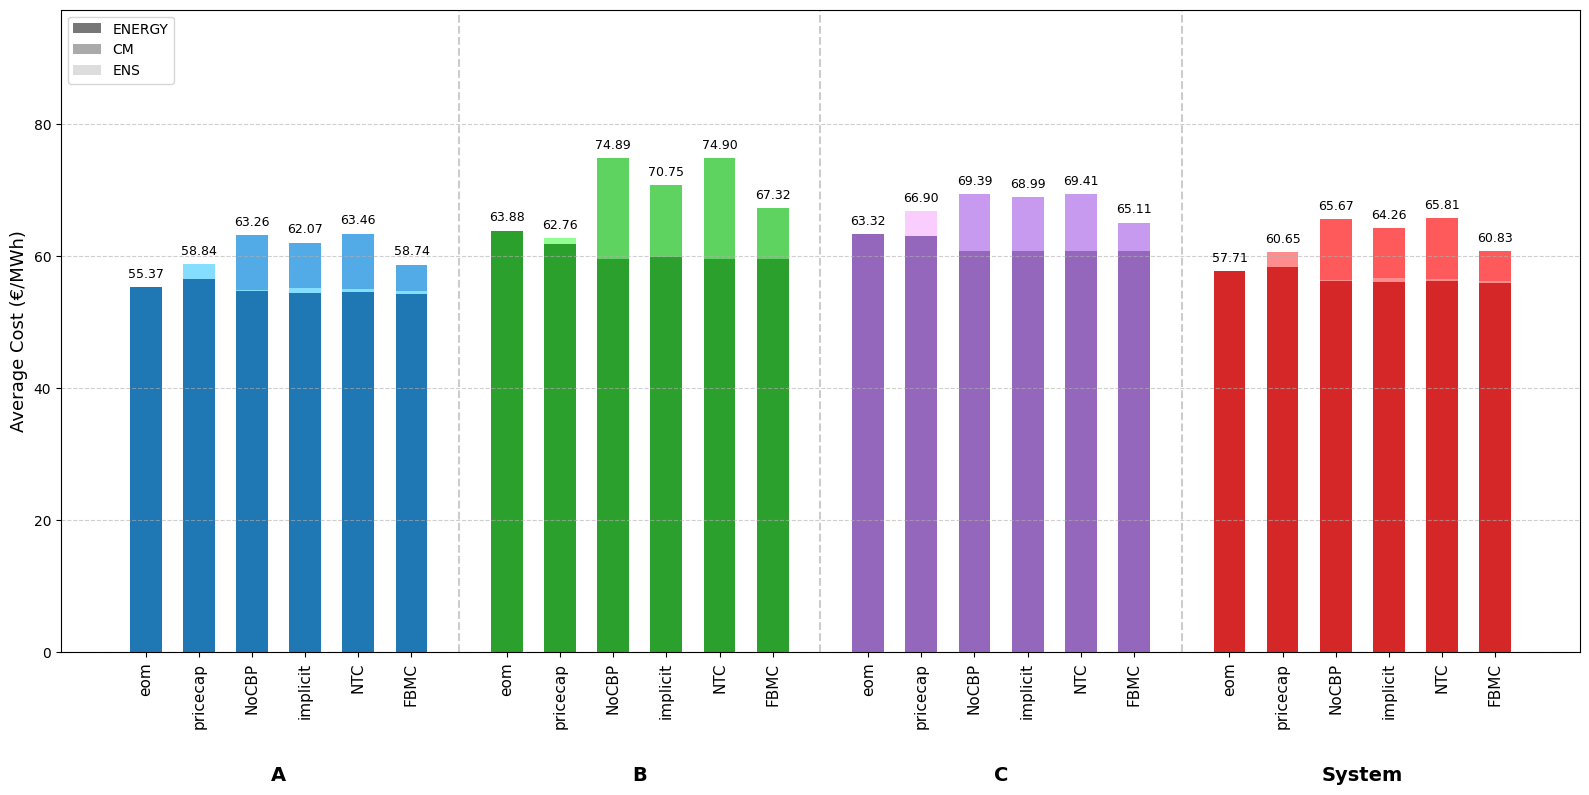

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,2.620311e+10,0.000000e+00,0.000000e+00,2.620311e+10,4.732061e+08,55.373562,0.00
1,B,eom,5.061400e+09,0.000000e+00,0.000000e+00,5.061400e+09,7.922850e+07,63.883582,0.00
2,C,eom,6.988248e+09,0.000000e+00,0.000000e+00,6.988248e+09,1.103562e+08,63.324476,0.00
3,System,eom,3.825275e+10,0.000000e+00,0.000000e+00,3.825275e+10,6.627908e+08,57.714676,0.00
4,A,pricecap,2.679099e+10,1.051672e+09,0.000000e+00,2.784266e+10,4.731644e+08,58.843525,52583.62
5,B,pricecap,4.905856e+09,6.643880e+07,0.000000e+00,4.972295e+09,7.922580e+07,62.761054,3321.94
6,C,pricecap,6.958591e+09,4.230044e+08,0.000000e+00,7.381595e+09,1.103351e+08,66.901601,21150.22
7,System,pricecap,3.865544e+10,1.541116e+09,0.000000e+00,4.019655e+10,6.627253e+08,60.653412,77055.78
8,A,NoCBP,2.588600e+10,8.016920e+07,3.970982e+09,2.993715e+10,4.732559e+08,63.257857,4008.46
9,B,NoCBP,4.723917e+09,0.000000e+00,1.210003e+09,5.933920e+09,7.923646e+07,74.888757,0.00


In [32]:
analyze_costs(analysis_data, inputs, source_type="planner")

In [33]:
def compare_mcp_planner_costs(analysis_data, inputs):
    """
    Create a component bar chart comparing MCP and planner cost results
    using consistent styling with other visualizations
    """
    # Get cost metrics for both sources
    mcp_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "mcp"), inputs["weights"])
    planner_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "planner"), inputs["weights"])
    
    # Filter to just get system-wide metrics
    mcp_system = mcp_metrics[mcp_metrics["Zone"] == "System"].copy()
    planner_system = planner_metrics[planner_metrics["Zone"] == "System"].copy()
    
    # Prepare data for plotting
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Set up parameters for plotting
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    bar_width = 0.35
    x = np.arange(len(design_order))
    
    # Use same color scheme as plot_average_cost_by_zone
    mcp_base = "#9467bd"     # Green (System color from plot_average_cost_by_zone)
    planner_base = "#C0C0C0"  # Gray (A color from plot_average_cost_by_zone)


    # Function to create shades (exactly as in plot_average_cost_by_zone)
    def get_shades(hex_color):
        rgb = mcolors.to_rgb(hex_color)
        return {
            "ENERGY": mcolors.to_hex(rgb),                           # original
            "CM": mcolors.to_hex([min(1, c + 0.1) for c in rgb]),   # medium lightness
            "ENS": mcolors.to_hex([min(1, c + 0.2) for c in rgb])    # lightest
        }
    
    # Get color shades for both sources
    mcp_colors = get_shades(mcp_base)
    planner_colors = get_shades(planner_base)
    
    # Track positions for bar labels
    mcp_heights = {}
    planner_heights = {}
    
    # Plot MCP costs
    for i, design in enumerate(design_order):
        mcp_row = mcp_system[mcp_system["Design"] == design]
        if not mcp_row.empty:
            # Calculate components per MWh
            energy = mcp_row["ElectricityCost"].values[0] / mcp_row["DemandServed"].values[0]
            ens = mcp_row["ENSCost"].values[0] / mcp_row["DemandServed"].values[0]
            cm = mcp_row["CapacityCost"].values[0] / mcp_row["DemandServed"].values[0]
            
            # Plot stacked bars with consistent naming (ENERGY instead of Energy)
            ax.bar(x[i] - bar_width/2, energy, width=bar_width, color=mcp_colors["ENERGY"], 
                   label="MCP ENERGY" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, ens, width=bar_width, bottom=energy, color=mcp_colors["ENS"], 
                   label="MCP ENS" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, cm, width=bar_width, bottom=energy+ens, color=mcp_colors["CM"], 
                   label="MCP CM" if i == 0 else "")
            
            # Store total height for labeling
            mcp_heights[design] = energy + ens + cm
    
    # Plot Planner costs
    for i, design in enumerate(design_order):
        planner_row = planner_system[planner_system["Design"] == design]
        if not planner_row.empty:
            # Calculate components per MWh
            energy = planner_row["ElectricityCost"].values[0] / planner_row["DemandServed"].values[0]
            ens = planner_row["ENSCost"].values[0] / planner_row["DemandServed"].values[0]
            cm = planner_row["CapacityCost"].values[0] / planner_row["DemandServed"].values[0]
            
            # Plot stacked bars with consistent naming
            ax.bar(x[i] + bar_width/2, energy, width=bar_width, color=planner_colors["ENERGY"], 
                   label="Planner ENERGY" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, ens, width=bar_width, bottom=energy, color=planner_colors["ENS"], 
                   label="Planner ENS" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, cm, width=bar_width, bottom=energy+ens, color=planner_colors["CM"], 
                   label="Planner CM" if i == 0 else "")
            
            # Store total height for labeling
            planner_heights[design] = energy + ens + cm
    
    # Add labels and values on top of bars
    for i, design in enumerate(design_order):
        if design in mcp_heights:
            ax.text(x[i] - bar_width/2, mcp_heights[design] + 1, f"{mcp_heights[design]:.1f}", 
                    ha='center', va='bottom', fontsize=9)
        if design in planner_heights:
            ax.text(x[i] + bar_width/2, planner_heights[design] + 1, f"{planner_heights[design]:.1f}", 
                    ha='center', va='bottom', fontsize=9)
    
    # Customize plot
    ax.set_ylabel('Average Cost (€/MWh)', fontsize=13)
    # ax.set_title('Comparison of Average System Costs: MCP vs Planner', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(design_order)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    
    # Create custom legend with patches using same style as plot_average_cost_by_zone
    legend_elements = [
        Patch(facecolor=mcp_colors["ENERGY"], label='MCP ENERGY'),
        Patch(facecolor=mcp_colors["CM"], label='MCP CM'),
        Patch(facecolor=mcp_colors["ENS"], label='MCP ENS'),
        Patch(facecolor=planner_colors["ENERGY"], label='Planner ENERGY'),
        Patch(facecolor=planner_colors["CM"], label='Planner CM'),
        Patch(facecolor=planner_colors["ENS"], label='Planner ENS'),

    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=8)
    
    plt.tight_layout()
    return fig, ax

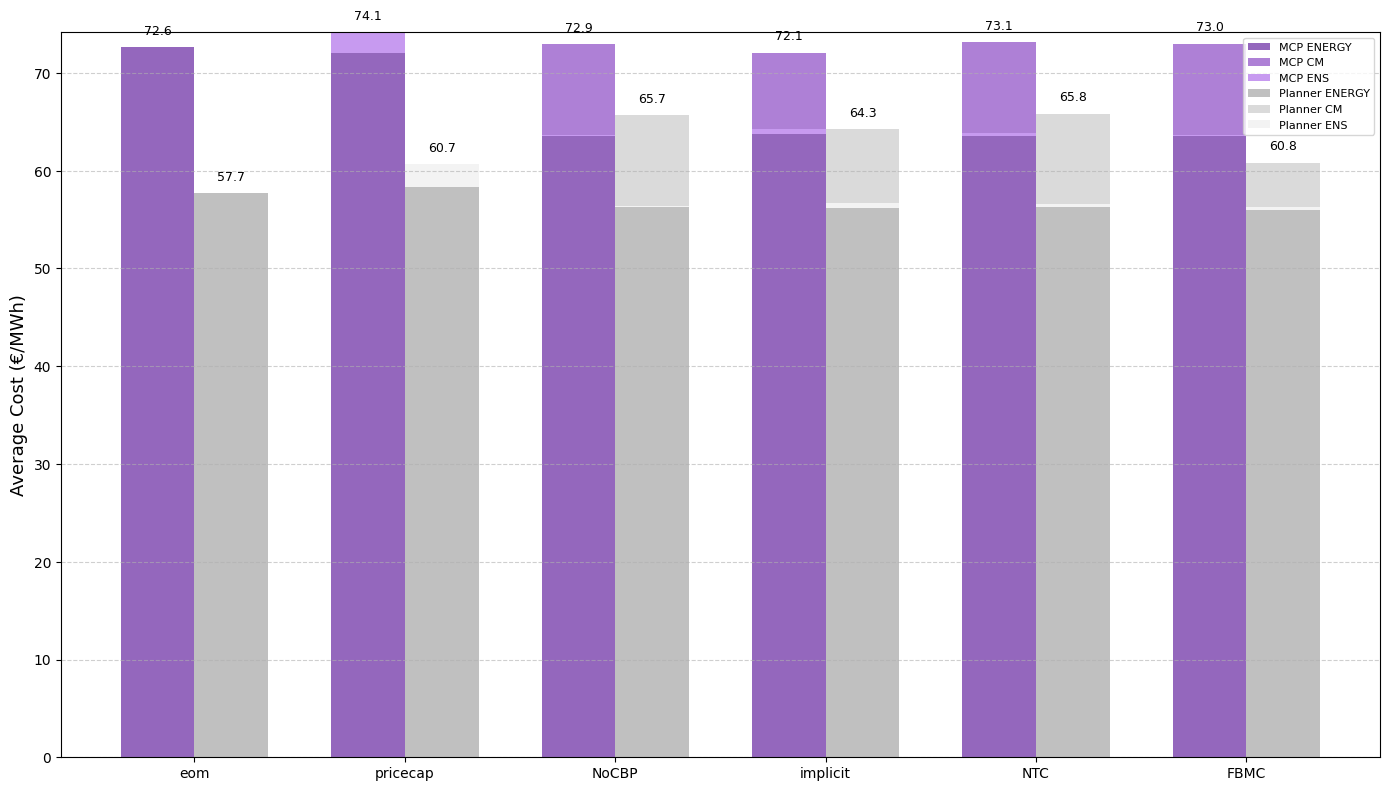

In [34]:
# function call
fig, ax = compare_mcp_planner_costs(analysis_data, inputs)

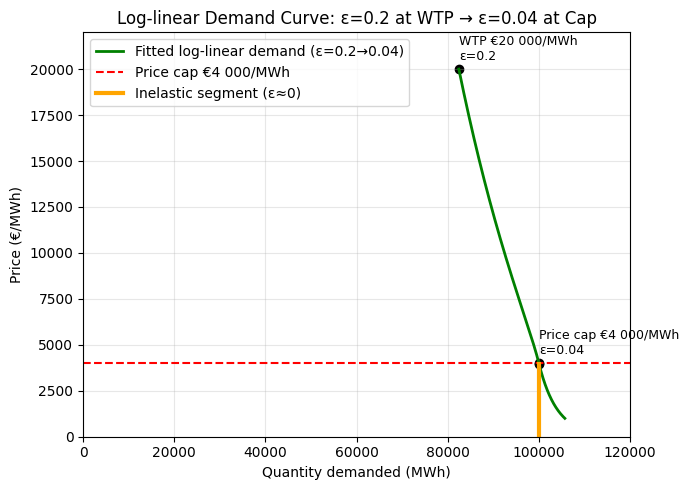

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz

# Calibration points
P1, eps1 = 20000, 0.2     # WTP point
P2, eps2 = 4000,  0.04    # price cap point

# Extend price grid below the cap
P_min = 1000
P = np.linspace(P1, P_min, 600)

# Log-linear interpolation of elasticity vs log(price)
eps_P = eps1 + (eps2 - eps1) * (np.log(P) - np.log(P1)) / (np.log(P2) - np.log(P1))
eps_P = np.clip(eps_P, eps2, eps1)  # prevent extrapolation below 0.04

# Integrate d(ln Q)/d(ln P) = -ε(P)
lnP = np.log(P)
lnQ = -cumtrapz(eps_P, lnP, initial=0)

# Normalize: Q(P2) = 10,000 MWh
Q_cap = 100000
idx_cap = np.argmin(np.abs(P - P2))
lnQ_shift = np.log(Q_cap) - lnQ[idx_cap]
lnQ += lnQ_shift
Q = np.exp(lnQ)

# Find "inelastic start" where ε ≈ 0.02
inelastic_threshold = 0.02
idx_inelastic = np.argmin(np.abs(eps_P - inelastic_threshold))
Q_inelastic = Q[idx_inelastic]
P_inelastic = P[idx_inelastic]

# --- Plot ---
plt.figure(figsize=(7,5))

# Demand curve
plt.plot(Q, P, lw=2, color="green", label="Fitted log-linear demand (ε=0.2→0.04)")

# Price cap line
plt.axhline(P2, color="red", ls="--", lw=1.5, label="Price cap €4 000/MWh")

# Inelastic (vertical) part starts *below* price cap
plt.plot([Q_inelastic, Q_inelastic], [0, P_inelastic],
         color="orange", lw=3, label="Inelastic segment (ε≈0)")

# Key points
plt.scatter([Q[0], Q_cap, Q_inelastic], [P1, P2, P_inelastic], color='black')
plt.text(Q[0]+20, P1+500, "WTP €20 000/MWh\nε=0.2", fontsize=9)
plt.text(Q_cap+50, P2+500, "Price cap €4 000/MWh\nε=0.04", fontsize=9)

# Axes and formatting
plt.xlim(0, 1.2*Q_cap)
plt.ylim(0, 22000)
plt.xlabel("Quantity demanded (MWh)")
plt.ylabel("Price (€/MWh)")
plt.title("Log-linear Demand Curve: ε=0.2 at WTP → ε=0.04 at Cap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
# Difference between planner and mcp designs

In [37]:
# scarcity prices across zones

### Sensitivity

In [38]:
# sensitivity of average cost to interconnector capacity